# **Lab4: Data Visualization**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**
**Student_Name** : Art Oudom
**ID** : 2025577

-----

**Objective:** In this lab, you will apply the data visualization techniques you have studied to a real dataset. Each graph you create should be easy to understand and complete, including a title, legend, and other information to help the audience comprehend them easily. Effective graphs shouldn't take longer than 15 seconds for viewers to understand.

- Or you can work directly with `Google Colab` here: [Lab4_Data_Visualization.ipynb](https://colab.research.google.com/drive/1SJ0Ft43NerqXn5fXUhJY6vHOrom96dF1?usp=sharing).

-----


# 1. `Gapminder` dataset

[`Gapminder`](https://pypi.org/project/gapminder/) is an excerpt of data available at [https://gapminder.org](https://www.gapminder.org/). For each of $142$ countries (`country`), the package provides values for life expectancy (`lifeExp`), GDP per capita (`gdpPercap`), and population (`pop`), every five years, from $1952$ to $2007$ (`year`). It is initially used in [Jennifer Bryan's excellent `gapminder` teaching package for R](https://github.com/jennybc/gapminder/) ([`ggplot`](https://ggplot2.tidyverse.org/), [`tidyverse`](https://www.tidyverse.org/), and more). For more information about `gapminder`:

- Documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).

In [1]:
from gapminder import gapminder as gm
import pandas as pd
import numpy as np
data = gm.copy()
data.head()
print(f'number of observations: {data.shape[0]}')

c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\gapminder\data.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


number of observations: 1704


----------

## **A. Variable types**

- Address dimension of the dataset.
- Which variables are considered quantitative and which are qualitative?
- Perform statistical summary on quantitative columns. Are there any missing values? Invalid data? Duplications? Outliers?
- Just take note if any problems above are detected but you don't need to handle them.

In [2]:
print(f'data dimensions: {data.shape[0]} rows and {data.shape[1]} columns')

data dimensions: 1704 rows and 6 columns


In [3]:
print(f'Quantitative columns are: {data.select_dtypes(include=np.number).columns.tolist()}\n'
      f'Quanlitative columns are: {data.select_dtypes(exclude=np.number).columns.tolist()}')

Quantitative columns are: ['year', 'lifeExp', 'pop', 'gdpPercap']
Quanlitative columns are: ['country', 'continent']


In [4]:
data.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [5]:
data.isna().sum()

country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

The data has already been preprocessed no invalid data no missing values no duplicated but has some on population columns and gdp

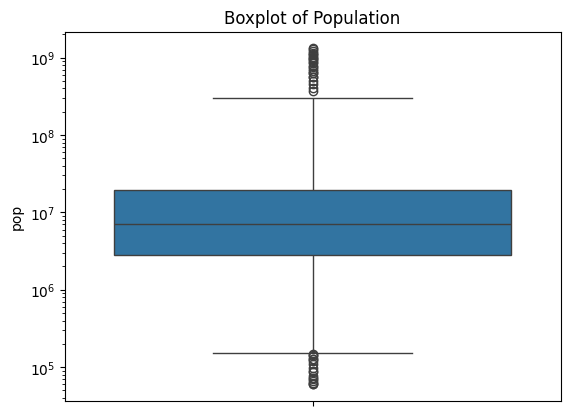

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot( data, y='pop' , log_scale=True) 
plt.title('Boxplot of Population')
plt.show()

## **B. Year 1952**

### **B.1 Quantitative vs quantitative**

- Create a subdataset called `data1952` that contains only the information in year 1952.
- View relation between `gdpPercap` and `lifeExp` in 1952.
- View relation between `gdpPercap` and `pop` in 1952.
- View relation between `lifeExp` and `pop` in 1952.
- Do they look different from year 2007?

`Hint`: You can produce the same graphs as shown in the course using `Plotly` package avaialble here: [plotly python](https://plotly.com/python/).

In [8]:
# To be continued in the next cell
data_1952 = data.query('year == 1952')
data_1952


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
12,Albania,Europe,1952,55.230,1282697,1601.056136
24,Algeria,Africa,1952,43.077,9279525,2449.008185
36,Angola,Africa,1952,30.015,4232095,3520.610273
48,Argentina,Americas,1952,62.485,17876956,5911.315053
...,...,...,...,...,...,...
1644,Vietnam,Asia,1952,40.412,26246839,605.066492
1656,West Bank and Gaza,Asia,1952,43.160,1030585,1515.592329
1668,"Yemen, Rep.",Asia,1952,32.548,4963829,781.717576
1680,Zambia,Africa,1952,42.038,2672000,1147.388831


In [9]:
import plotly.express as px

fig = px.scatter(
    data_1952,
    x='gdpPercap',
    y='lifeExp',
    color='continent',
    size='gdpPercap',
    size_max=40,
    hover_name='country',
    log_x=True,
    opacity=0.7,
    title='Life Expectancy vs GDP per Capita (1952)',
    labels={
        'gdpPercap': 'GDP per Capita',
        'lifeExp': 'Life Expectancy'
    }
)

fig.update_layout(width=900, height=600)
fig.show()

In [10]:
import plotly.express as px



fig = px.scatter(
    data_1952,
    x='gdpPercap',
    y='lifeExp',
    color='continent',
    size='pop',
    size_max=60,
    hover_name='country',
    log_x=True,
    opacity=0.7,
    title='Life Expectancy vs GDP per Capita (1952)',
    labels={
        'gdpPercap': 'GDP per Capita',
        'lifeExp': 'Life Expectancy'
    }
)
fig.update_layout(autosize=True, height=700)
fig.show(config={'responsive': True})

In [11]:

fig = px.scatter(
    data_1952,
    x='pop',
    y='gdpPercap',
    color='continent',
    hover_name='country',
    log_x=True,
    log_y=True,
    opacity=0.7,
    title='GDP per Capita vs Population (1952)',
    labels={'pop': 'Population (log scale)', 'gdpPercap': 'GDP per Capita (log scale)'}
)
fig.update_layout(width=900, height=600)
fig.show()

# correlate the LOGGED values, because the log axes are what the eye is reading off the chart
r = np.corrcoef(np.log10(data_1952['pop']), np.log10(data_1952['gdpPercap']))[0, 1]
print(f'correlation between log(pop) and log(gdpPercap) in 1952: {r:.3f}')

correlation between log(pop) and log(gdpPercap) in 1952: 0.011


In [12]:

fig = px.scatter(
    data_1952,
    x='pop',
    y='lifeExp',
    color='continent',
    hover_name='country',
    log_x=True,
    opacity=0.7,
    title='Life Expectancy vs Population (1952)',
    labels={'pop': 'Population (log scale)', 'lifeExp': 'Life Expectancy (years)'}
)
fig.update_layout(width=900, height=600)
fig.show()

r = np.corrcoef(np.log10(data_1952['pop']), data_1952['lifeExp'])[0, 1]
print(f'correlation between log(pop) and lifeExp in 1952: {r:.3f}')

correlation between log(pop) and lifeExp in 1952: 0.154


In [13]:

data_two_years = data.query('year in [1952, 2007]')

fig = px.scatter(
    data_two_years,
    x='gdpPercap',
    y='lifeExp',
    color='continent',
    size='pop',
    size_max=45,
    hover_name='country',
    log_x=True,
    opacity=0.7,
    facet_col='year',
    title='Life Expectancy vs GDP per Capita: 1952 vs 2007 (bubble size = population)',
    labels={'gdpPercap': 'GDP per Capita (log scale)', 'lifeExp': 'Life Expectancy (years)'}
)
fig.update_layout(width=1100, height=550)
fig.show()

summary = data_two_years.groupby('year').agg(
    lifeExp_min=('lifeExp', 'min'),
    lifeExp_median=('lifeExp', 'median'),
    lifeExp_max=('lifeExp', 'max'),
    gdp_min=('gdpPercap', 'min'),
    gdp_median=('gdpPercap', 'median'),
    gdp_max=('gdpPercap', 'max'),
).round(2)
print(summary.to_string())

for yr in (1952, 2007):
    sub = data_two_years.query('year == @yr')
    # correlate against log(gdpPercap): life expectancy rises linearly with log money, not raw money
    r_gdp = np.corrcoef(np.log10(sub['gdpPercap']), sub['lifeExp'])[0, 1]
    r_pop = np.corrcoef(np.log10(sub['pop']), sub['lifeExp'])[0, 1]
    print(f'{yr}: corr(log gdpPercap, lifeExp) = {r_gdp:.3f}   corr(log pop, lifeExp) = {r_pop:.3f}')

      lifeExp_min  lifeExp_median  lifeExp_max  gdp_min  gdp_median    gdp_max
year                                                                          
1952        28.80           45.14        72.67   298.85     1968.53  108382.35
2007        39.61           71.94        82.60   277.55     6124.37   49357.19
1952: corr(log gdpPercap, lifeExp) = 0.748   corr(log pop, lifeExp) = 0.154
2007: corr(log gdpPercap, lifeExp) = 0.809   corr(log pop, lifeExp) = 0.065


In [14]:
viet_nam = data.query('country == "Vietnam" and year == 2007')
viet_nam

,country,continent,year,lifeExp,pop,gdpPercap
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404


**Do they look different from 2007?**
tbh yes they are look different from 2007 because 1952 is a peak cold war era between US and USSR which some country have a civil war due to political analogy conflict or is under colonialism unlike 2007 we are in a peaceful world and countries developed in thier own pace:
- for instance 
 vietnam in 1952 : due to intense vietnam war vietnam(both south and north) have a unhealty life expentancy quality with life expentancy 40.412 and 605.1 gdp per capita.
 vietnam in 2007: countries are developing in thier own pace multiple clothing brand open thier factory in it country and had 2441.57 gdp per capita and 74.249 life expentacy which is acceptable.

- According to the data, in 1952:
    - Which country was the richest?
    - Which country was the poorest?
    - Which country was the healthiest?
    - Which country was the unhealthiest?

In [25]:
# To do
richest_country = data_1952.query("gdpPercap == gdpPercap.max()")
richest_country

,country,continent,year,lifeExp,pop,gdpPercap,lifeExpQual
852,Kuwait,Asia,1952,55.565,160000,108382.3529,healthy


In [27]:
poorest_country = data_1952.query("gdpPercap == gdpPercap.min()")
poorest_country

,country,continent,year,lifeExp,pop,gdpPercap,lifeExpQual
876,Lesotho,Africa,1952,42.138,748747,298.846212,moderate


In [30]:
healthiest_country =  data_1952.query("lifeExp == lifeExp.max()")
healthiest_country

,country,continent,year,lifeExp,pop,gdpPercap,lifeExpQual
1140,Norway,Europe,1952,72.67,3327728,10095.42172,healthy


- Repeat the previous question for the year 1977. Before computing, can you guess which country had the lowest life expectancy around that year?

it cambodia 


In [16]:
# To do
data_1977 = data.query('year == 1977')
lowest_life_expectancy_1977 = data_1977.loc[data_1977['lifeExp'].idxmin()]
print(f"The country with the lowest life expectancy in 1977 is {lowest_life_expectancy_1977['country']} with a life expectancy of {lowest_life_expectancy_1977['lifeExp']} years.")

The country with the lowest life expectancy in 1977 is Cambodia with a life expectancy of 31.22 years.


### **B.2. Quatitative vs qualitative**

- We observed differences in health conditions across continents in 2007. Was this also the case in 1952? Please visualize your findings.
- What about the economy? Visualize and explain your results.

In [36]:
ordered_cols = ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap']
fig_box = px.box(
    data_1952,
    x='continent',
    y='lifeExp',
    color='continent',
    title='Life Expectancy by Continent (1952)',
    labels={'lifeExp': 'Life Expectancy (years)', 'continent': 'Continent'},
    category_orders={'continent': ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']}
)
fig_box.update_layout(width=900, height=600,title='Life Expectancy by Continent (1952)')
fig_box.show()

In [35]:
data_1952.groupby('continent')['lifeExp'].mean().sort_values(ascending=False)

continent
Oceania     69.255000
Europe      64.408500
Americas    53.279840
Asia        46.314394
Africa      39.135500
Name: lifeExp, dtype: float64

In [34]:
data_1952.groupby('continent')['gdpPercap'].mean().sort_values(ascending=False)

continent
Oceania     10298.085650
Europe       5661.057435
Asia         5195.484004
Americas     4079.062552
Africa       1252.572466
Name: gdpPercap, dtype: float64

- **Health (`lifeExp`)**: Europe and Oceania have the highest life expectancy in 1952, and Africa has
  the lowest median (38.8). The *spread* is a separate story from the *level*: the widest box is the
  Americas (IQR 14.16), then Asia (11.52); Africa is one of the tightest (IQR 6.31, narrower than
  Europe's 6.79). So African countries in 1952 are uniformly low, not widely scattered.
- **Economy (`gdpPercap`)**: Europe, the Americas and Oceania have noticeably higher median GDP per
  capita than Africa and Asia. Every outlier on this panel is on the **high** side — there are no
  low-end outliers on any continent. Africa's are Angola, Gabon and South Africa; Asia's are Bahrain
  and Kuwait (108382, far above everything else).
- Oceania is hard to interpret because the continent has only two datapoints, but it shows the
  highest GDP per capita and life expectancy.

### **B.3. Qualitative vs qualitative**

Qualitative variables are simpler than quantitative ones, as we primarily focus on the proportion or frequency of each category. In our dataset, the existing qualitative variables are not suitable for analysis because they are repeated each year. Therefore, we will create a new qualitative `lifeExp`.

- Add to the data `data1952` a column `lifeExpQual` containing three categories: [**"unhealthy"**, **"moderate"**, **"healthy"**] by splitting `lifeExp` into 3 classes.

> Hint: you may cheat using [slide 15](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Data_Visualization.html#/bivariate-visualization-8). The function `pd.qcut` is helpful for such a task.

- Graphically represent the connection between `lifeExpQual` and `continent` in year 1952.
- Describe what you see.

In [51]:
# To do
data_1952 = data_1952.copy()
data_1952['lifeExpQual'] = pd.qcut(
    data_1952['lifeExp'],
    q=3,
    labels=['unhealthy', 'moderate', 'healthy']
)

# Cross-tabulation of counts
ct = pd.crosstab(data_1952['continent'], data_1952['lifeExpQual'])
print(ct)

# Reshape counts to long format for Plotly (no division into proportions)
ct_long = ct.reset_index().melt(id_vars='continent', var_name='lifeExpQual', value_name='count')

# Stacked bar chart (counts) to visualize the relationship
fig = px.histogram(
    ct_long,
    x='continent',
    y='count',
    color='lifeExpQual',
    category_orders={'lifeExpQual': ['unhealthy', 'moderate', 'healthy']},
    color_discrete_map={
        'unhealthy': "#750600",
        'moderate': '#fee08b',
        'healthy': '#1a9850'
    },
    title='Number of Countries by Life Expectancy Category and Continent (1952)',
    labels={'continent': 'Continent', 'count': 'Number of Countries', 'lifeExpQual': 'lifeExpQual'}
)

fig.update_layout(
    barmode='stack',
    width=800,
    height=550
)

fig.show()

lifeExpQual  unhealthy  moderate  healthy
continent                                
Africa              35        17        0
Americas             2        13       10
Asia                11        14        8
Europe               0         3       27
Oceania              0         0        2


- Almost all African countries fall into the "unhealthy" category and none are "healthy" in 1952,
- while nearly all European countries are "healthy". Asia and the Americas are mixed, and Oceania
-  (only 2 countries) is entirely "moderate"/"healthy". This confirms the strong association between
- continent and life expectancy category seen in the boxplots above.

## **C. Time evolution**

`Gapminder` captures global changes from $1952$ to $2007$. It is more insightful to examine how these variables evolve over time.

### **C.1. Evolution of average `lifeExp` of the $5$ continents**

1. Create a line plot of `lifeExp` for the five continents from $1952$ to $2007$ using `sns.lineplot`. What observations can you make from the plot?

In [41]:
# To do
lifeExp_by_year = data.groupby(['year', 'continent'], as_index=False)['lifeExp'].mean()

fig = px.line(
    lifeExp_by_year,
    x='year',
    y='lifeExp',
    color='continent',
    markers=True,
    title='Evolution of Average Life Expectancy by Continent (1952-2007)',
    labels={'year': 'Year', 'lifeExp': 'Average Life Expectancy', 'continent': 'Continent'}
)

fig.update_layout(width=900, height=600)
fig.show()


- Life expectancy has increased over time for all five continents. Oceania and Europe consistently
  have the highest life expectancy, while Africa consistently has the **lowest level** — but Africa is
  *not* the slowest grower. Gains from 1952 to 2007: Asia **+24.4**, Americas **+20.3**, Africa
  **+15.7**, Europe **+13.2**, Oceania **+11.5**. Europe and Oceania rise least because they start
  near the ceiling and have the least room left.
- Africa's curve does flatten badly from 1987 to 2002 (53.3 → 53.6 → 53.6 → 53.3) before turning up
  again to 54.8 in 2007 — a plateau widely attributed to the HIV/AIDS epidemic.
- Asia shows the fastest overall improvement, closing the gap with the Americas from **7.0** years in
  1952 (53.3 vs 46.3) to **2.9** years in 2007 (73.6 vs 70.7).

### **C.2. Other variables**

- Repeat the same process with `pop`, and then with `gdpPercap`. Provide your comments for each case.

In [46]:
# To do
pop_by_year = data.groupby(['year', 'continent'], as_index=False)['pop'].sum()
gdp_by_year = data.groupby(['year', 'continent'], as_index=False)['gdpPercap'].mean()

fig = px.line(pop_by_year, x='year',
        y='pop', color='continent', 
        markers=True, title='Total Population by Continent (1952-2007)', 
        labels={'year': 'Year', 'pop': 'Total Population', 'continent': 'Continent'})
fig.update_layout(width=800, height=600)
fig.show()

fig2 = px.line(gdp_by_year, x='year',
        y='gdpPercap', color='continent',
        markers=True, title='Average GDP per Capita by Continent (1952-2007)',
        labels={'year': 'Year', 'gdpPercap': 'Average GDP per Capita', 'continent': 'Continent'})
fig2.update_layout(width=800, height=600)
fig2.show()

- **Population**: Asia's population has grown dramatically and dominates the total (1395M in 1952 to
  3812M in 2007), far outpacing every other continent, while Oceania remains nearly flat and small in
  comparison (10.7M to 24.5M). Africa grows fastest in relative terms (237M to 930M, 3.91x vs Asia's
  2.73x) and overtakes the Americas between 2002 (833.7M vs 849.8M) and 2007 (929.5M vs 898.9M).
- **GDP per capita**: Oceania, Europe and the Americas all grow steadily, with Oceania and Europe
  pulling ahead over time (29810 and 25054 by 2007). Africa grows only slightly (1253 to 3089) and
  stays far below the others.
- Asia does **not** start from a low base on this chart, even though the underlying countries are
  poor: Asia's 1952 mean is **5195**, *above* the Americas (4079) and close to Europe (5661). The mean
  is dragged up by Kuwait at 108382. For the same reason Asia's line *falls* from 1972 to 1982
  (8187 → 7791 → 7434) as Kuwait's GDP per capita collapses, then resumes growing. Plotting the
  **median** instead of the mean would remove Kuwait's distortion and show the low-base story
  honestly.

### **C.3. Cambodia**

- Plot the evolution of the three quantitative variables for **Cambodia**. What do you observe?

In [ ]:
# To do
cambodia = data.query("country in ['Cambodia', 'Thailand' ]")
fig = px.line(
    cambodia,
    x='year',
    y='lifeExp',
    color='country',
    markers=True,
    title='Life Expectancy in Cambodia and Thailand (1952-2007)',
    labels={'year': 'Year', 'lifeExp': 'Life Expectancy', 'country': 'Country'}
)
fig.update_layout(width=900, height=600)
fig.show()



In [ ]:
# To do
cambodia = data.query("country in ['Cambodia', 'Thailand']")
fig = px.line(
    cambodia,
    x='year',
    y='gdpPercap',
    color='country',
    markers=True,
    title='GDP per Capita in Cambodia and Thailand (1952-2007)',
    labels={'year': 'Year', 'gdpPercap': 'GDP per Capita', 'country': 'Country'}
)
fig.update_layout(width=900, height=600)
fig.show()

- Cambodia's life expectancy shows a dramatic, sharp drop in the mid-to-late 1970s, coinciding with
- the Khmer Rouge regime and civil war, before recovering steadily afterward. Population dipped
 slightly in that same period (instead of following the steady growth seen elsewhere) before resuming
 growth. GDP per capita stayed very low and roughly flat for decades, only beginning a modest, more
- visible recovery from the 1990s onward. All three variables clearly reflect the impact of that period
 of conflict on the country.

# Further readings
- Gapminder documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).
- Graphical tools:
    - [`matplotlib`](https://matplotlib.org/stable/index.html)
    - [`seaborn`](https://seaborn.pydata.org/)
    - [`https://plotly.com/python/`](https://plotly.com/python/)